In [1]:
import pandas as pd

df = pd.read_csv("../data/owid-covid-data.csv", parse_dates=["date"])

print("Shape:", df.shape)
print("\nMissing values (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))
df.head(3)

Shape: (429435, 67)

Missing values (top 10):
weekly_icu_admissions                      418442
weekly_icu_admissions_per_million          418442
excess_mortality                           416024
excess_mortality_cumulative_absolute       416024
excess_mortality_cumulative                416024
excess_mortality_cumulative_per_million    416024
weekly_hosp_admissions                     404938
weekly_hosp_admissions_per_million         404938
icu_patients_per_million                   390319
icu_patients                               390319
dtype: int64


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [2]:
exclude = [
    "World", "Asia", "Europe", "Africa",
    "North America", "South America", "Oceania",
    "European Union", "High income", "Low income",
    "Upper middle income", "Lower middle income", "International"
]

df = df[~df["location"].isin(exclude)].copy()
print(f"Countries remaining: {df['location'].nunique()}")

Countries remaining: 248


In [3]:
cols = [
    "location", "continent", "date", "population",
    "total_cases", "new_cases",
    "total_deaths", "new_deaths",
    "total_vaccinations",
    "people_fully_vaccinated_per_hundred",
    "total_cases_per_million",
    "total_deaths_per_million"
]

df = df[cols].copy()
print("Shape after selecting columns:", df.shape)

Shape after selecting columns: (417680, 12)


In [4]:
df["new_cases"] = df["new_cases"].clip(lower=0)
df["new_deaths"] = df["new_deaths"].clip(lower=0)

df["total_cases"] = df.groupby("location")["total_cases"].ffill()
df["total_deaths"] = df.groupby("location")["total_deaths"].ffill()
df["total_vaccinations"] = df.groupby("location")["total_vaccinations"].ffill()

print("Done cleaning!")

Done cleaning!


In [5]:
df["case_fatality_rate"] = (
    (df["total_deaths"] / df["total_cases"]) * 100
).round(2)

df["total_cases_M"] = (df["total_cases"] / 1e6).round(3)
df["total_deaths_M"] = (df["total_deaths"] / 1e6).round(3)

print("New columns added successfully")
df.head(3)

New columns added successfully


,location,continent,date,population,total_cases,new_cases,total_deaths,new_deaths,total_vaccinations,people_fully_vaccinated_per_hundred,total_cases_per_million,total_deaths_per_million,case_fatality_rate,total_cases_M,total_deaths_M
0,Afghanistan,Asia,2020-01-05,41128772,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,0.0,0.0
1,Afghanistan,Asia,2020-01-06,41128772,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,0.0,0.0
2,Afghanistan,Asia,2020-01-07,41128772,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,0.0,0.0


In [6]:
latest = (
    df.sort_values("date")
    .groupby("location")
    .last()
    .reset_index()
)

latest = latest.dropna(subset=["continent"])
print(f"Countries in snapshot: {len(latest)}")
latest.head(3)

Countries in snapshot: 243


,location,continent,date,population,total_cases,new_cases,total_deaths,new_deaths,total_vaccinations,people_fully_vaccinated_per_hundred,total_cases_per_million,total_deaths_per_million,case_fatality_rate,total_cases_M,total_deaths_M
0,Afghanistan,Asia,2024-08-04,41128772,235214.0,0.0,7998.0,0.0,22964750.0,44.67,5796.47,197.10,3.40,0.235,0.008
1,Albania,Europe,2024-08-04,2842318,335047.0,0.0,3605.0,0.0,3088966.0,45.01,118491.02,1274.93,1.08,0.335,0.004
2,Algeria,Africa,2024-08-04,44903228,272139.0,18.0,6881.0,0.0,15267442.0,14.43,5984.05,151.31,2.53,0.272,0.007


In [7]:
df.to_csv("../data/covid_clean.csv", index=False)
latest.to_csv("../data/latest_snapshot.csv", index=False)
print("Saved: covid_clean.csv and latest_snapshot.csv")

Saved: covid_clean.csv and latest_snapshot.csv


In [2]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("../data/covid_clean.csv", parse_dates=["date"])
latest = pd.read_csv("../data/latest_snapshot.csv")

print("df shape:", df.shape)
print("latest shape:", latest.shape)

df shape: (417680, 15)
latest shape: (243, 15)


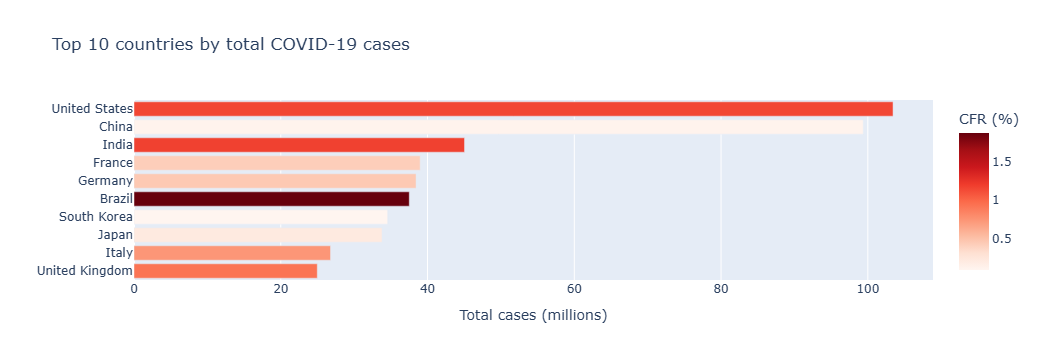

In [4]:
top10 = latest.nlargest(10, "total_cases")[
    ["location", "total_cases_M", "total_deaths_M", "case_fatality_rate"]
]

fig = px.bar(
    top10,
    x="total_cases_M",
    y="location",
    orientation="h",
    color="case_fatality_rate",
    color_continuous_scale="Reds",
    title="Top 10 countries by total COVID-19 cases",
    labels={
        "total_cases_M": "Total cases (millions)",
        "location": "",
        "case_fatality_rate": "CFR (%)"
    }
)
fig.update_layout(yaxis=dict(autorange="reversed"))
fig.show()

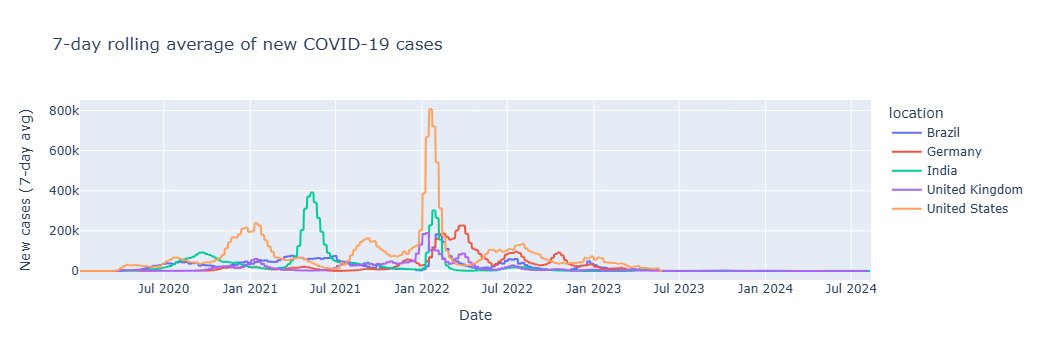

In [6]:
countries = ["United States", "India", "Brazil", "Germany", "United Kingdom"]
df_sub = df[df["location"].isin(countries)].copy()

df_sub["new_cases_7d"] = (
    df_sub
    .groupby("location")["new_cases"]
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
    .round(0)
)

fig = px.line(
    df_sub,
    x="date",
    y="new_cases_7d",
    color="location",
    title="7-day rolling average of new COVID-19 cases",
    labels={"new_cases_7d": "New cases (7-day avg)", "date": "Date"}
)
fig.show()

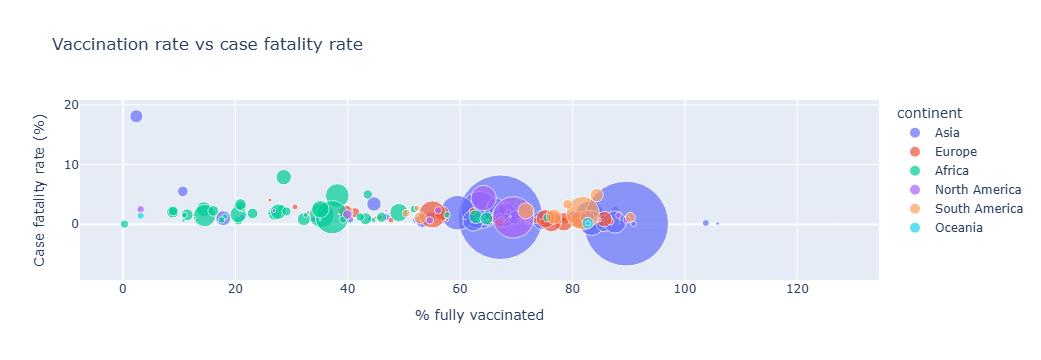

In [7]:
vax_df = latest.dropna(subset=[
    "people_fully_vaccinated_per_hundred",
    "case_fatality_rate"
])

fig = px.scatter(
    vax_df,
    x="people_fully_vaccinated_per_hundred",
    y="case_fatality_rate",
    size="population",
    color="continent",
    hover_name="location",
    title="Vaccination rate vs case fatality rate",
    labels={
        "people_fully_vaccinated_per_hundred": "% fully vaccinated",
        "case_fatality_rate": "Case fatality rate (%)"
    },
    size_max=60
)
fig.show()

C:\Users\Trilo\AppData\Local\Temp\ipykernel_15204\1231618349.py:1: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


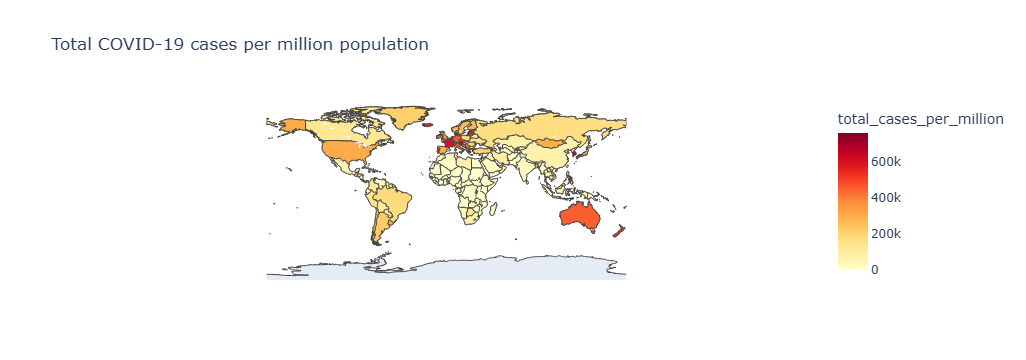

In [8]:
fig = px.choropleth(
    latest,
    locations="location",
    locationmode="country names",
    color="total_cases_per_million",
    hover_name="location",
    hover_data={
        "total_deaths_M": True,
        "case_fatality_rate": True,
        "people_fully_vaccinated_per_hundred": True,
        "total_cases_per_million": True
    },
    color_continuous_scale="YlOrRd",
    title="Total COVID-19 cases per million population"
)
fig.update_layout(geo=dict(showframe=False, showcoastlines=True))
fig.show()